In [ ]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.tree import DecisionTreeClassifier
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import time
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier



In [21]:

column_names = [
    'letter', 'x-box', 'y-box', 'width', 'height', 'onpix', 'x-bar',
    'y-bar', 'x2bar', 'y2bar', 'xybar', 'x2ybr', 'xy2br',
    'x-ege', 'xegvy', 'y-ege', 'yegvx'
]

df = pd.read_csv('letter-recognition.data', header=None, names=column_names)

print("Shape of dataset:", df.shape)



Shape of dataset: (20000, 17)


In [4]:
print(df.head())


  letter  x-box  y-box  width  height  onpix  x-bar  y-bar  x2bar  y2bar  \
0      T      2      8      3       5      1      8     13      0      6   
1      I      5     12      3       7      2     10      5      5      4   
2      D      4     11      6       8      6     10      6      2      6   
3      N      7     11      6       6      3      5      9      4      6   
4      G      2      1      3       1      1      8      6      6      6   

   xybar  x2ybr  xy2br  x-ege  xegvy  y-ege  yegvx  
0      6     10      8      0      8      0      8  
1     13      3      9      2      8      4     10  
2     10      3      7      3      7      3      9  
3      4      4     10      6     10      2      8  
4      6      5      9      1      7      5     10  


Descriptive statistics:
              x-box         y-box         width       height         onpix  \
count  20000.000000  20000.000000  20000.000000  20000.00000  20000.000000   
mean       4.023550      7.035500      5.121850      5.37245      3.505850   
std        1.913212      3.304555      2.014573      2.26139      2.190458   
min        0.000000      0.000000      0.000000      0.00000      0.000000   
25%        3.000000      5.000000      4.000000      4.00000      2.000000   
50%        4.000000      7.000000      5.000000      6.00000      3.000000   
75%        5.000000      9.000000      6.000000      7.00000      5.000000   
max       15.000000     15.000000     15.000000     15.00000     15.000000   

              x-bar         y-bar         x2bar         y2bar         xybar  \
count  20000.000000  20000.000000  20000.000000  20000.000000  20000.000000   
mean       6.897600      7.500450      4.628600      5.178650      8.282050   
std        2.026035      2.325354   

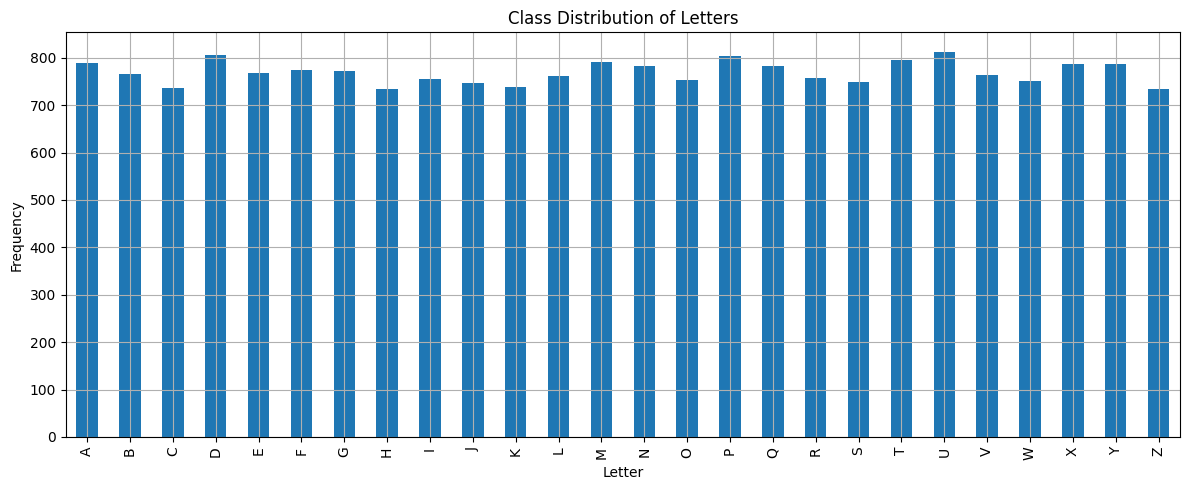

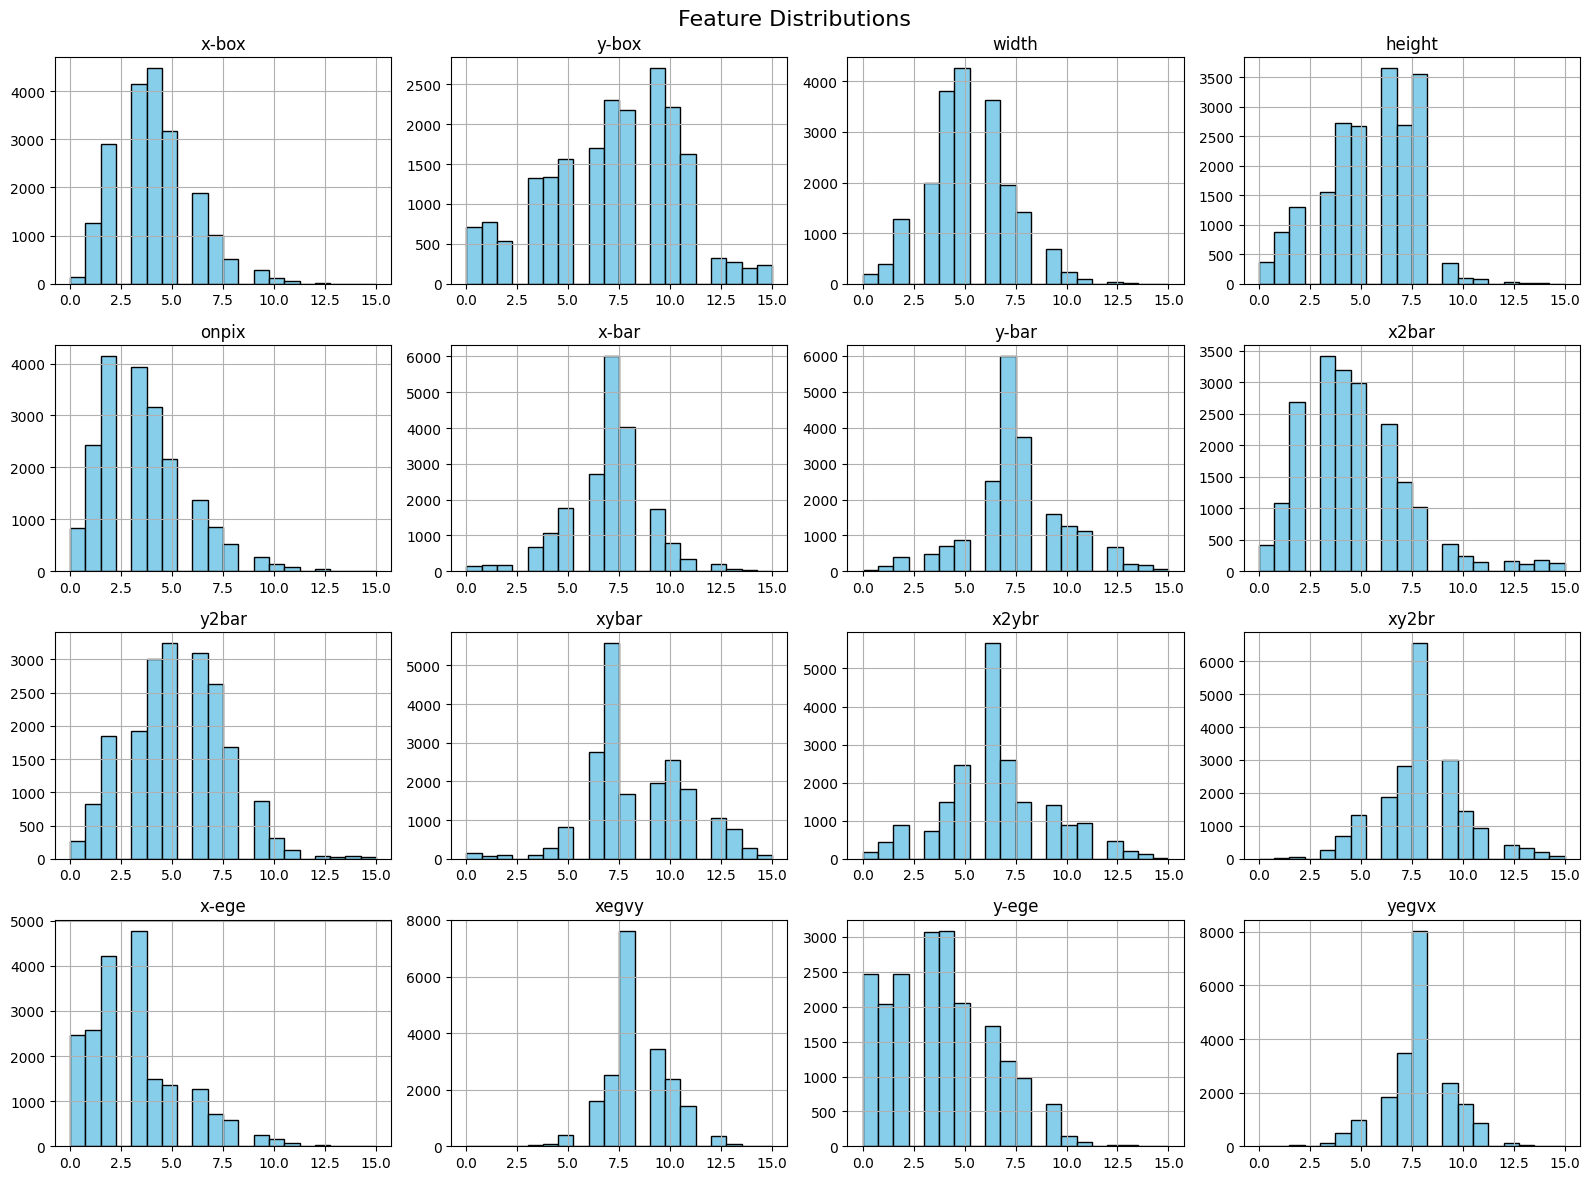

In [6]:
print("Descriptive statistics:")
print(df.describe())



plt.figure(figsize=(12, 5))
df['letter'].value_counts().sort_index().plot(kind='bar')
plt.title("Class Distribution of Letters")
plt.xlabel("Letter")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()



features = df.columns[1:]  

df[features].hist(bins=20, figsize=(16, 12), color='skyblue', edgecolor='black')
plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

In [8]:
X = df.drop('letter', axis=1)
y = df['letter']

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [10]:

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])


Training samples: 16000
Test samples: 4000


In [12]:

def create_bootstrap_tree(X, y, max_features_ratio=0.5, max_depth=None, min_samples_split=2):
    n_samples = X.shape[0]
    n_features = X.shape[1]
    bootstrap_indices = np.random.choice(n_samples, size=n_samples, replace=True)
    feature_indices = np.random.choice(n_features, size=int(n_features * max_features_ratio), replace=False)
    X_sample = X[bootstrap_indices][:, feature_indices]
    y_sample = y[bootstrap_indices]
    tree = DecisionTreeClassifier(max_depth=max_depth, min_samples_split=min_samples_split)
    tree.fit(X_sample, y_sample)
    return tree, feature_indices

trees = []
feature_sets = []

start_time = time.time()
for _ in range(50):
    tree, features = create_bootstrap_tree(X_train, y_train, max_features_ratio=0.5, max_depth=15, min_samples_split=5)
    trees.append(tree)
    feature_sets.append(features)
end_time = time.time()

print("Total training time (50 trees):", end_time - start_time, "seconds")


Total training time (50 trees): 3.67911696434021 seconds


In [ ]:

def bootstrap_sample(X, y):
    n_samples, n_features = X.shape
    sample_idx = np.random.choice(n_samples, n_samples, replace=True)
    feature_idx = np.random.choice(n_features, int(np.sqrt(n_features)), replace=False)
    return X[sample_idx][:, feature_idx], y[sample_idx], feature_idx

def build_random_forest(X, y, n_estimators=50):
    trees = []
    feature_sets = []
    start = time.perf_counter()
    for _ in range(n_estimators):
        X_boot, y_boot, feat_idx = bootstrap_sample(X, y)
        tree = DecisionTreeClassifier(criterion='entropy', max_depth=None,
                                      min_samples_split=2, min_samples_leaf=1)
        tree.fit(X_boot, y_boot)
        trees.append(tree)
        feature_sets.append(feat_idx)
    duration = time.perf_counter() - start
    return trees, feature_sets, duration

trees, feature_sets, training_time = build_random_forest(X_train, y_train, n_estimators=50)
print("Training time (s):", training_time)
print("Number of trees:", len(trees))


Training time (s): 2.460080999999718
Number of trees: 50


In [ ]:


predictions = []

for tree, feat_idx in zip(trees, feature_sets):
    preds = tree.predict(X_test[:, feat_idx])
    predictions.append(preds)

predictions = np.array(predictions).T
predictions_df = pd.DataFrame(predictions)
print(predictions_df.shape)


(4000, 50)


In [15]:
predictions

array([[15, 17,  6, ..., 17, 17, 15],
       [12, 12, 16, ..., 12, 12, 12],
       [ 1, 11, 10, ...,  1,  1,  1],
       ...,
       [ 0, 11,  4, ..., 23, 23, 23],
       [ 2,  2, 22, ...,  6, 16, 16],
       [20, 20,  8, ..., 20,  7, 11]])

In [19]:

n_classes = len(np.unique(y_train))
n_trees = len(trees)
n_test = X_test.shape[0]

# hard voting
hard_preds = np.empty((n_test, n_trees), dtype=int)
for i, (tree, idx) in enumerate(zip(trees, feature_sets)):
    hard_preds[:, i] = tree.predict(X_test[:, idx])
majority = np.array([np.bincount(row, minlength=n_classes).argmax() for row in hard_preds])
acc_hard = accuracy_score(y_test, majority)

# soft voting
avg_proba = np.zeros((n_test, n_classes))
for tree, idx in zip(trees, feature_sets):
    avg_proba += tree.predict_proba(X_test[:, idx])
avg_proba /= n_trees
soft_pred = avg_proba.argmax(axis=1)
acc_soft = accuracy_score(y_test, soft_pred)

# weighted voting (weights = accuracy on training set)
weights = np.array([tree.score(X_train[:, idx], y_train) for tree, idx in zip(trees, feature_sets)])
weighted_proba = np.zeros((n_test, n_classes))
for w, (tree, idx) in zip(weights, zip(trees, feature_sets)):
    weighted_proba += w * tree.predict_proba(X_test[:, idx])
weighted_pred = weighted_proba.argmax(axis=1)
acc_weighted = accuracy_score(y_test, weighted_pred)

print("Accuracy hard voting:", acc_hard)
print("Accuracy soft voting:", acc_soft)
print("Accuracy weighted voting:", acc_weighted)


Accuracy hard voting: 0.879
Accuracy soft voting: 0.91075
Accuracy weighted voting: 0.9135


In [ ]:


def bootstrap_indices(n):
    return np.random.choice(n, n, replace=True)
models = []
probas = []
n_train = X_train.shape[0]
n_classes = len(np.unique(y_train))
for _ in range(15):
    idx = bootstrap_indices(n_train)
    lr = LogisticRegression(max_iter=1000)
    lr.fit(X_train[idx], y_train[idx])
    models.append(lr)
for _ in range(15):
    idx = bootstrap_indices(n_train)
    knn = KNeighborsClassifier()
    knn.fit(X_train[idx], y_train[idx])
    models.append(knn)
for _ in range(15):
    idx = bootstrap_indices(n_train)
    gnb = GaussianNB()
    gnb.fit(X_train[idx], y_train[idx])
    models.append(gnb)
for _ in range(15):
    idx = bootstrap_indices(n_train)
    feat = np.random.choice(X_train.shape[1], int(np.sqrt(X_train.shape[1])), replace=False)
    dt = DecisionTreeClassifier(criterion='entropy')
    dt.fit(X_train[idx][:, feat], y_train[idx])
    models.append((dt, feat))

soft_sum = np.zeros((X_test.shape[0], n_classes))
hard_preds = np.empty((X_test.shape[0], 60), dtype=int)

for i, m in enumerate(models):
    if isinstance(m, tuple):
        clf, f = m
        p = clf.predict_proba(X_test[:, f])
        pred = p.argmax(axis=1)
    else:
        p = m.predict_proba(X_test)
        pred = p.argmax(axis=1)
    soft_sum += p
    hard_preds[:, i] = pred
soft_avg = soft_sum / 60
soft_vote = soft_avg.argmax(axis=1)
hard_vote = np.apply_along_axis(lambda row: np.bincount(row, minlength=n_classes).argmax(), 1, hard_preds)
acc_soft = accuracy_score(y_test, soft_vote)
acc_hard = accuracy_score(y_test, hard_vote)
print("Accuracy soft voting:", acc_soft)
print("Accuracy hard voting:", acc_hard)


Accuracy soft voting: 0.90075
Accuracy hard voting: 0.85975


In [26]:
hard_preds = np.empty((X_test.shape[0], len(trees)), dtype=int)
for i, (tree, idx) in enumerate(zip(trees, feature_sets)):
    hard_preds[:, i] = tree.predict(X_test[:, idx])
majority = np.apply_along_axis(lambda r: np.bincount(r, minlength=len(np.unique(y_train))).argmax(), 1, hard_preds)
acc_custom = accuracy_score(y_test, majority)
time_custom = training_time

start = time.perf_counter()
rf = RandomForestClassifier(n_estimators=50, criterion='entropy', max_features='sqrt', bootstrap=True, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
time_builtin = time.perf_counter() - start
acc_builtin = accuracy_score(y_test, rf.predict(X_test))

print("Custom RF accuracy:", acc_custom)
print("Custom RF training time (s):", time_custom)
print("Built-in RF accuracy:", acc_builtin)
print("Built-in RF training time (s):", time_builtin)


Custom RF accuracy: 0.879
Custom RF training time (s): 2.460080999999718
Built-in RF accuracy: 0.96675
Built-in RF training time (s): 0.9415322999993805
